In [1]:
# Import necessary libraries for data manipulation and analysis
import numpy as np # Numerical operations
import pandas as pd # Data manipulation
from datetime import datetime, timedelta # Date operations

#Import necessary libraries for transformations
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy import stats
from scipy.stats import skew, kurtosis

# Import libraries for plotting and visualization
import matplotlib.pyplot as plt # Matplotlib for basic plotting
import seaborn as sns # Seaborn for enhanced visualization
import plotly.express as px # Plotly for interactive plots

# Import libraries for time series analysis and modeling
from statsmodels.tsa.stattools import adfuller # Augmented Dickey-Fuller Test for stationarity check
from statsmodels.tsa.stattools import kpss # Kwiatkowski-Phillips-Schmidt-Shin Test for stationarity check
from statsmodels.tsa.statespace.sarimax import SARIMAX # SARIMAX model for time series forecasting
from statsmodels.tsa.seasonal import seasonal_decompose # Seasonal decomposition for trend, seasonal, and residual components
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima #SARIMAX using pmdarima

# Import necessary libraries for computing acf and pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf  # For autocorrelation and partial autocorrelation plots
from statsmodels.tsa.stattools import acf, pacf  # For computing autocorrelation and partial autocorrelation

#Import libraries for multicollineaarity
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Import libraries for transformations
import joblib



In [2]:
from SARIMAX import remove_multicollinear, calculate_vif
import datascript
from datascript import load_data, split_data
import os

SARIMAX for Luzon
DATA PREPROCESSING

In [3]:
#Import the necessary files
base_path = os.path.dirname(os.path.abspath(datascript.__file__))  # Gets the current working directory
complete_luz_gwap = load_data("LUZ",'GWAP', features = False, transformed=False)
complete_luz_lwap = load_data("LUZ",'LWAP', features = False, transformed=False)

In [4]:
GWAP = load_data("LUZ",'GWAP', model='SARIMAX', features = False, transformed=True)
LWAP = load_data("LUZ",'LWAP', model='SARIMAX', features = False, transformed=True)

GWAP_transformed_features = load_data("LUZ",'GWAP', model='SARIMAX', features = True, transformed=True)

In [5]:
%run SARIMAX.py
#Prepare exogenous variables and check for multicollinearity
full_transformed_exog = GWAP_transformed_features.drop(columns=['GWAP'])
full_transformed_exog = full_transformed_exog.shift(1)
full_transformed_exog = full_transformed_exog.fillna(0)
full_exog_train, full_exog_test = split_data(full_transformed_exog, False)

exog_train = remove_multicollinear(full_exog_train, 10)
calculate_vif(exog_train)

final_exog = drop_unmatched_columns(full_transformed_exog, exog_train)

Dropping TMIN_Tanay with VIF of 108.33328364846425
Dropping TMAX_Clark with VIF of 93.05653071843075
Dropping TMAX_NAIA with VIF of 77.13698049203796
Dropping TMIN_Clark with VIF of 61.987909168034065
Dropping TMAX_Tayabas with VIF of 61.490494337799426
Dropping TMIN_NAIA with VIF of 56.57052248213269
Dropping TMAX_CLSU with VIF of 54.61911408613607
Dropping TMAX_Science Garden with VIF of 53.292559557436114
Dropping TMAX_Calapan with VIF of 52.362281365321415
Dropping TMIN_Casiguran with VIF of 51.53854389567617
Dropping TMAX_Tanay with VIF of 44.26876807875707
Dropping Demand with VIF of 40.63564443324962
Dropping TMIN_CLSU with VIF of 35.74155225851787
Dropping TMAX_Ambulong with VIF of 30.61913466612185
Dropping TMIN_Calapan with VIF of 27.36782045475102
Dropping TMAX_Cubi Point with VIF of 24.66484292429846
Dropping TMIN_Cubi Point with VIF of 24.388953143442215
Dropping Reserve_GWAP_Ru with VIF of 22.364813350706154
Dropping TMAX_Casiguran with VIF of 20.53430801367261
Dropping T

In [6]:
#Prepare the necessary datasets
#Target Variables
GWAP_train, GWAP_test = split_data(GWAP, False)
LWAP_train, LWAP_test = split_data(LWAP, False)

#Untransformed variables for verification 
untransformed_GWAP_train, untransformed_GWAP_test = split_data(complete_luz_gwap, False)
untransformed_LWAP_train, untransformed_LWAP_test = split_data(complete_luz_lwap, False)



/opt/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  v = v.dt.to_pydatetime()
/opt/anaconda3/lib/python3.11/site-packages/_plotly_utils/basevalidators.py:106: FutureWarning:

The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result



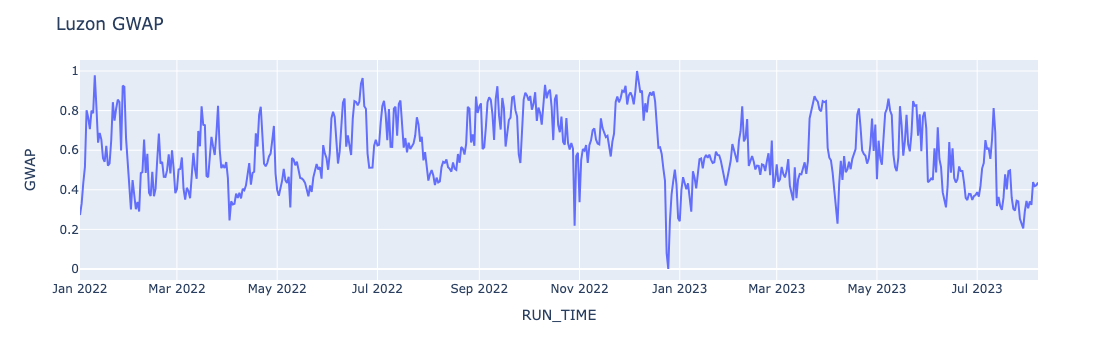

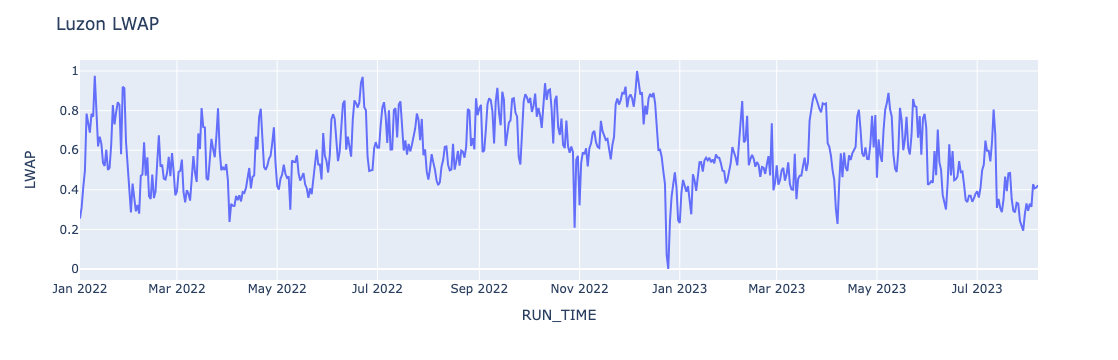

In [7]:
#Plotting Train LWAP ang GWAP
# Create the line plot
gwap_plot = px.line(GWAP_train, x=GWAP_train.index, y='GWAP')
lwap_plot = px.line(LWAP_train, x=LWAP_train.index, y='LWAP')
# Set the title using the ticker value
gwap_plot.update_layout(title=f"Luzon GWAP")
lwap_plot.update_layout(title=f"Luzon LWAP")
# Display the plot
gwap_plot.show()
lwap_plot.show()

Differencing

In [8]:
%run SARIMAX.py

#Checking for stationarity in GWAP data
differenced_GWAP = perform_differencing(GWAP_train, GWAP)
differenced_LWAP = perform_differencing(LWAP_train, LWAP)

GWAP_train, GWAP_test = split_data(differenced_GWAP, False)
LWAP_train, LWAP_test = split_data(differenced_LWAP, False)

Data is stationary after differencing 0 times.
Data is stationary after differencing 0 times.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:65: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:65: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




In [9]:
#Perform differencing on train exogenous data
diff_full_exog = perform_df_differencing(exog_train, final_exog)
diff_full_exog = diff_full_exog.fillna(0)
exog_train, exog_test = split_data(diff_full_exog, False)

/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: Inte

Column 'FLOW_LUZ' is stationary after differencing 0 times.
Column 'Reserve_GWAP_Fr' is stationary after differencing 0 times.
Column 'Reserve_GWAP_Rd' is stationary after differencing 1 times.
Column 'Reserve_GWAP_Dr' is stationary after differencing 1 times.
Column 'RAINFALL_Cubi Point' is stationary after differencing 0 times.
Column 'RAINFALL_NAIA' is stationary after differencing 1 times.
Column 'RAINFALL_Science Garden' is stationary after differencing 0 times.
Column 'TMIN_Science Garden' is stationary after differencing 1 times.
Column 'RAINFALL_San Jose' is stationary after differencing 0 times.
Column 'TMIN_San Jose' is stationary after differencing 1 times.
Column 'RAINFALL_Tayabas' is stationary after differencing 0 times.
Column 'RAINFALL_CLSU' is stationary after differencing 1 times.
Column 'RAINFALL_Tanay' is stationary after differencing 1 times.
Column 'RAINFALL_Ambulong' is stationary after differencing 0 times.
Column 'RAINFALL_Casiguran' is stationary after differe

/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.


/Users/ac/Desktop/SARIMAX-GARCH_FINAL (March 22)/SARIMAX.py:96: Inte

Order Specification

The ACF for GWAP is seen below
The PACF for GWAP is seen below


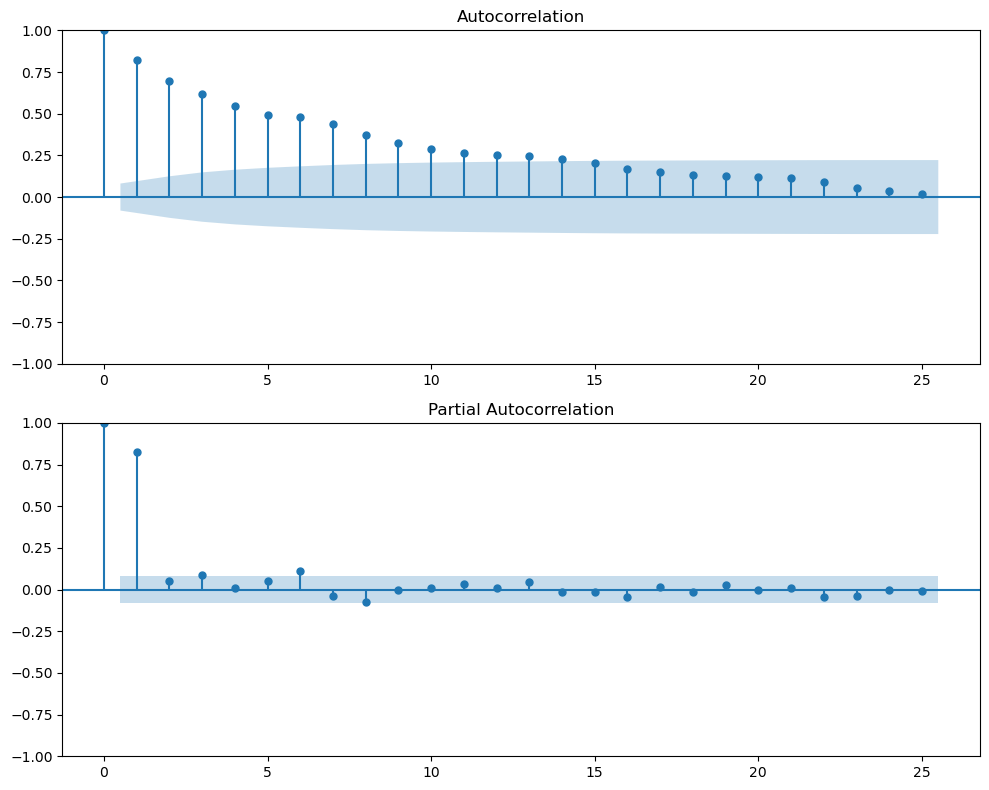

The ACF for LWAP is seen below
The PACF for LWAP is seen below


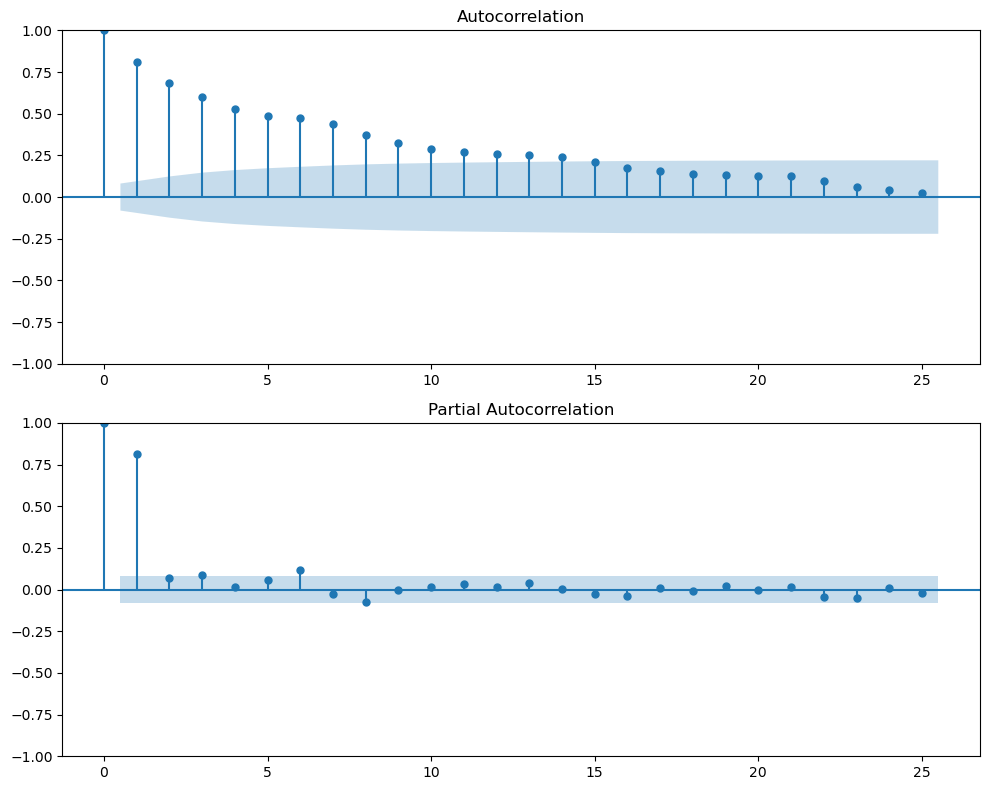

In [10]:
%run SARIMAX.py
plot_orders(GWAP_train, lags=25, alpha=0.05, var='GWAP')
plot_orders(LWAP_train, lags=25, alpha=0.05, var='LWAP')

GWAP and LWAP Forecasting

In [ ]:
%run SARIMAX.py
#Run seasonal_auto_arima function on GWAP 
#Use max_p and max_q based on acf and pacf plots
GWAP_sarimax = seasonal_auto_arima(GWAP_train, max_p=1, max_d=2, max_q=13, exog_data=exog_train )

#Display results of previous function
GWAP_sarimax

In [ ]:
%run SARIMAX.py
#Run seasonal_auto_arima function on GWAP 
#Use max_p and max_q based on acf and pacf plots
LWAP_sarimax = seasonal_auto_arima(LWAP_train, max_p=1, max_d=2, max_q=14, exog_data=exog_train )

#Display results of previous function
LWAP_sarimax

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



Optimization terminated successfully.
         Current function value: -0.953165
         Iterations: 11
         Function evaluations: 2065
                                     SARIMAX Results                                     
Dep. Variable:                              GWAP   No. Observations:                  584
Model:             SARIMAX(1, 1, 1)x(0, 0, 1, 6)   Log Likelihood                 556.649
Date:                           Sun, 23 Mar 2025   AIC                          -1071.297
Time:                                   12:46:55   BIC                           -979.565
Sample:                               01-01-2022   HQIC                         -1035.542
                                    - 08-07-2023                                         
Covariance Type:                             opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/opt/anaconda3/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



Optimization terminated successfully.
         Current function value: -0.928000
         Iterations: 11
         Function evaluations: 2080
                                     SARIMAX Results                                      
Dep. Variable:                               LWAP   No. Observations:                  584
Model:             SARIMAX(1, 1, 1)x(1, 0, [], 7)   Log Likelihood                 541.952
Date:                            Sun, 23 Mar 2025   AIC                          -1041.904
Time:                                    12:46:57   BIC                           -950.172
Sample:                                01-01-2022   HQIC                         -1006.148
                                     - 08-07-2023                                         
Covariance Type:                              opg                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

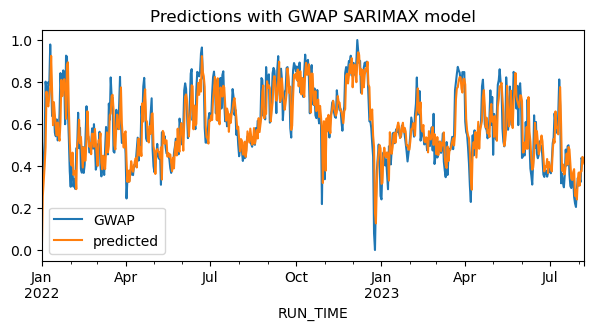

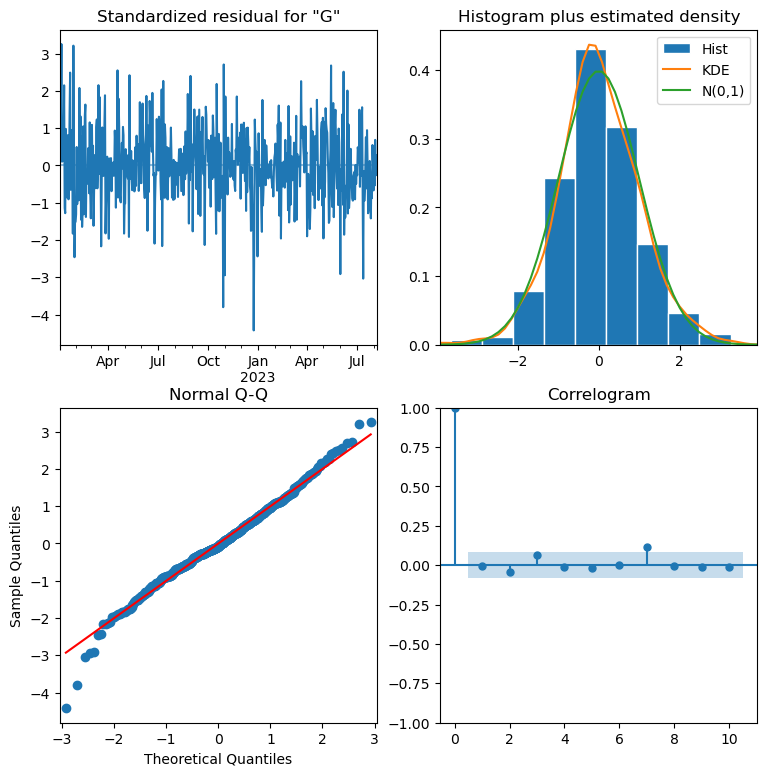

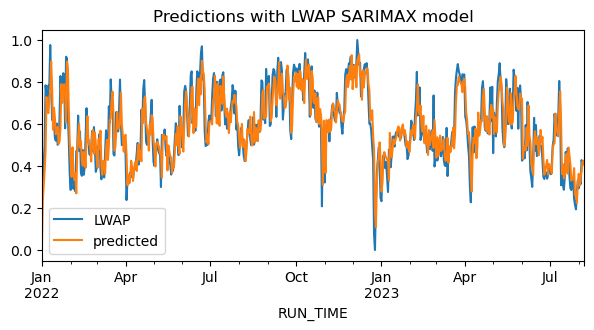

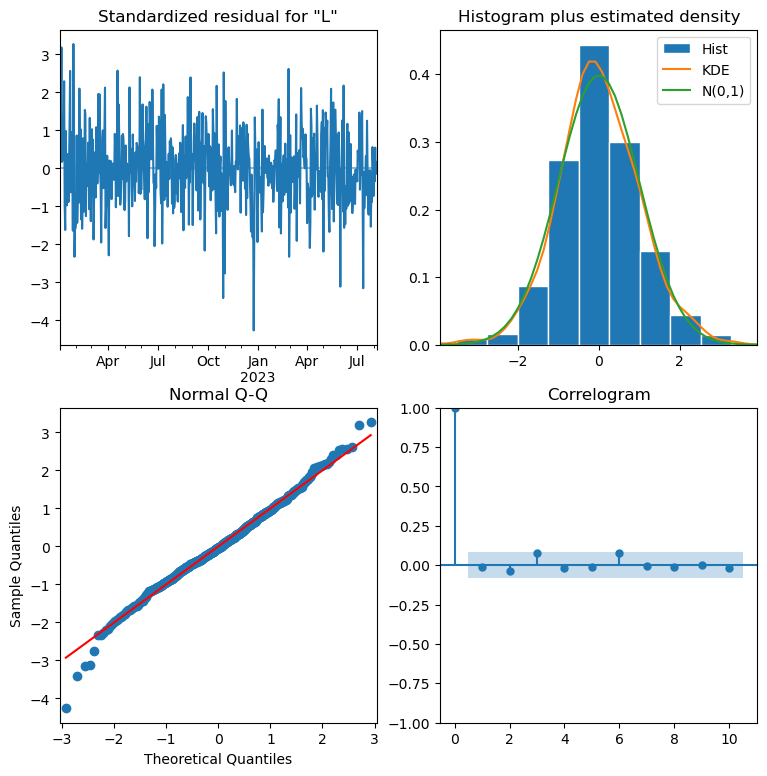

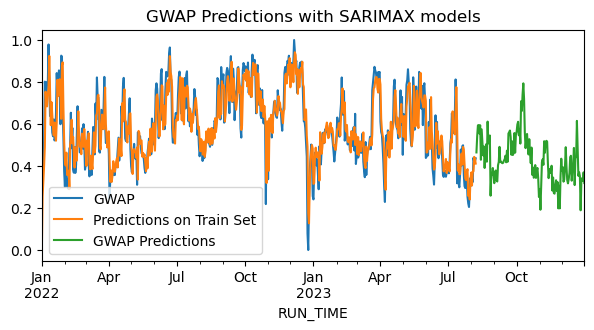

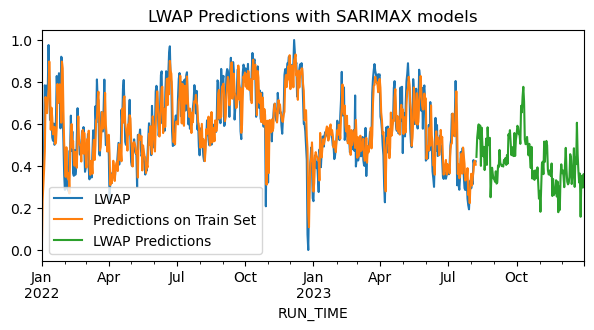

In [11]:
#Optimized orders for GWAP are (1,1,1)(0,0,1,6) and for LWAP are (1,1,1)(1,0,0)(7)
#This function fits the model and plots predictions on the train set; shows the summary of results and residuals diagnostics; and predicts on train set
%run SARIMAX.py

gwap_model_results, lwap_model_results, gwap_test_predict, lwap_test_predict, gwap_train_predict, lwap_train_predict = fit_SARIMAX(gwap_endog=GWAP_train, lwap_endog= LWAP_train, train_exog=exog_train, gwap_order=(1,1,1), gwap_seasonal_order=(0,0,1,6), lwap_order = (1,1,1), lwap_seasonal_order=(1,0,0,7), GWAP_test=GWAP_test, LWAP_test=LWAP_test, exog_test = exog_test)

GWAP Residual Analysis

In [12]:
#Generate residuals for GWAP
%run GARCH.py

gwap_resid_complete, gwap_resid_train = generate_resid(
    'GWAP',
    GWAP_train,
    GWAP_test,
    gwap_train_predict,
    gwap_test_predict,
    gwap_model_results
)

2022-01-01    0.272171
2022-01-02    0.074060
2022-01-03    0.106687
2022-01-04    0.116260
2022-01-05    0.311895
2022-01-06    0.009884
2022-01-07    0.010621
2022-01-08    0.116310
2022-01-09    0.054091
2022-01-10    0.203685
2022-01-11   -0.107793
2022-01-12   -0.120909
2022-01-13    0.092706
2022-01-14   -0.050219
2022-01-15   -0.080594
2022-01-16   -0.040323
2022-01-17    0.076665
2022-01-18   -0.085297
2022-01-19   -0.011938
2022-01-20    0.128617
2022-01-21    0.233832
2022-01-22   -0.061204
2022-01-23    0.076985
2022-01-24    0.089140
2022-01-25    0.030123
2022-01-26   -0.171238
2022-01-27    0.300967
2022-01-28    0.040425
2022-01-29   -0.230232
2022-01-30   -0.142379
2022-01-31   -0.141372
2022-02-01   -0.122332
2022-02-02    0.046330
2022-02-03   -0.096875
2022-02-04   -0.055590
2022-02-05   -0.030992
2022-02-06   -0.087229
2022-02-07    0.194128
2022-02-08   -0.012655
2022-02-09    0.123025
2022-02-10   -0.135664
2022-02-11    0.073168
2022-02-12   -0.153659
2022-02-13 

RUN_TIME
2022-01-01    0.272171
2022-01-02    0.074060
2022-01-03    0.106687
2022-01-04    0.116260
2022-01-05    0.311895
2022-01-06    0.009884
2022-01-07    0.010621
2022-01-08    0.116310
2022-01-09    0.054091
2022-01-10    0.203685
2022-01-11   -0.107793
2022-01-12   -0.120909
2022-01-13    0.092706
2022-01-14   -0.050219
2022-01-15   -0.080594
2022-01-16   -0.040323
2022-01-17    0.076665
2022-01-18   -0.085297
2022-01-19   -0.011938
2022-01-20    0.128617
2022-01-21    0.233832
2022-01-22   -0.061204
2022-01-23    0.076985
2022-01-24    0.089140
2022-01-25    0.030123
2022-01-26   -0.171238
2022-01-27    0.300967
2022-01-28    0.040425
2022-01-29   -0.230232
2022-01-30   -0.142379
2022-01-31   -0.141372
2022-02-01   -0.122332
2022-02-02    0.046330
2022-02-03   -0.096875
2022-02-04   -0.055590
2022-02-05   -0.030992
2022-02-06   -0.087229
2022-02-07    0.194128
2022-02-08   -0.012655
2022-02-09    0.123025
2022-02-10   -0.135664
2022-02-11    0.073168
2022-02-12   -0.153659
20

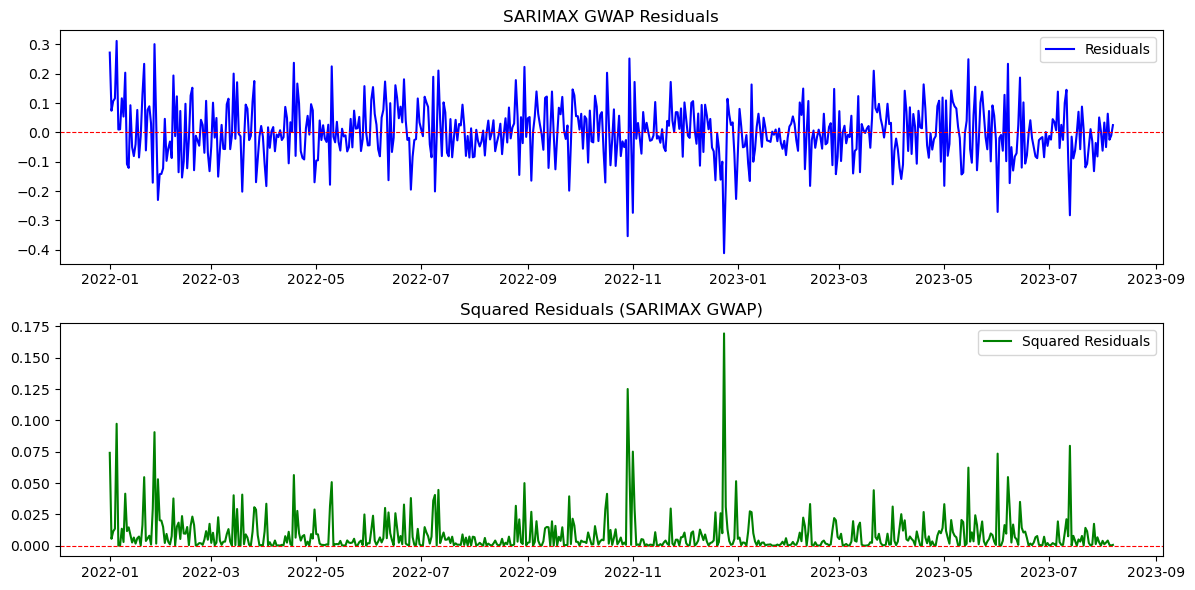

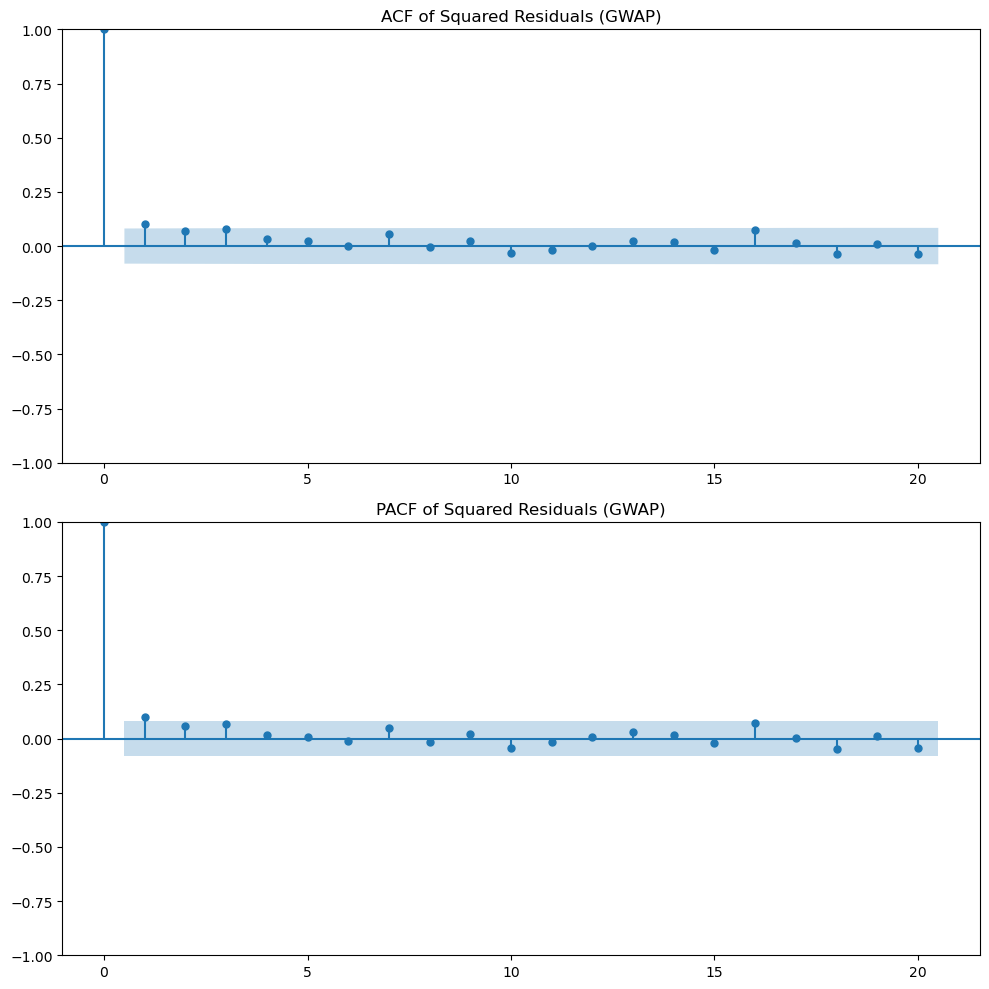

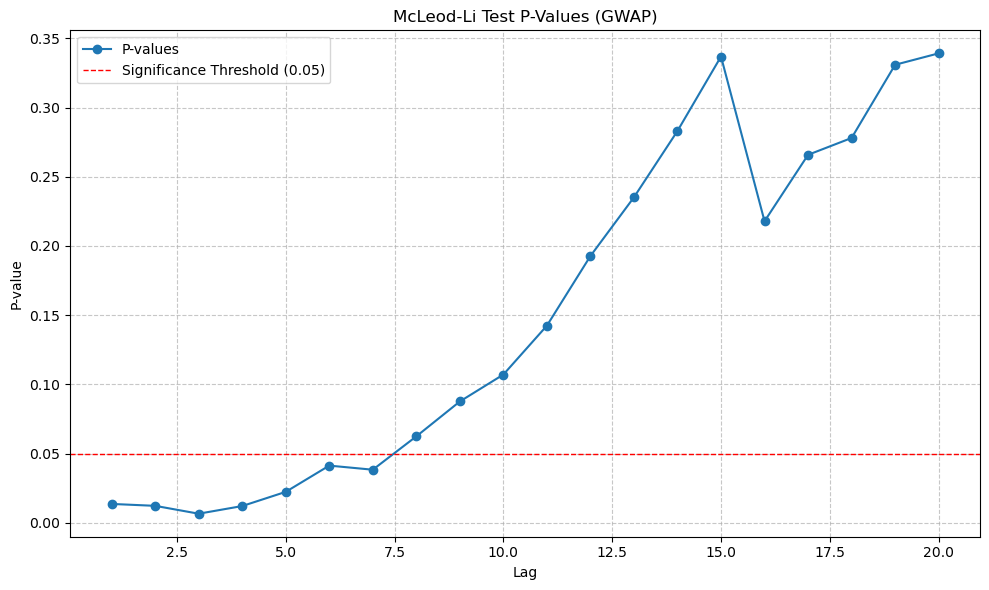

,Lag,PQ Test Stat,PQ p-value,LM Test Stat,LM p-value
0,1,6.078932,0.013680,6.231392,0.012551
1,2,8.795918,0.012302,8.594466,0.013606
2,3,12.234745,0.006621,11.027620,0.011577
3,4,12.827413,0.012151,11.038041,0.026140
4,5,13.107138,0.022395,11.847166,0.036943
5,6,13.107191,0.041365,13.218855,0.039689
6,7,14.818638,0.038396,15.268865,0.032703
7,8,14.832472,0.062486,15.365304,0.052420
8,9,15.119929,0.087694,15.420320,0.080019
9,10,15.746137,0.107134,16.339622,0.090314


In [13]:
#Conducting residual analysis
%run GARCH.py

garch_testing(gwap_resid_train, 'GWAP', max_lag=20)

In [14]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    gwap_resid_train, 
    vol="GARCH", 
    p_orders=[0,1], 
    q_orders=[0,1], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for GARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with ged distribution: One of p or o must be strictly positive


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.008799. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.008799. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scal

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1
0,1,1,GARCH,t,-1132.480010,-1115.000406,570.240005,16.339622,0.090314,0.118444,0.043832,0.726253,2.295502e-09
1,1,1,GARCH,ged,-1130.384089,-1112.904485,569.192044,16.339622,0.090314,0.108851,0.053564,0.731555,7.794911e-10
2,1,0,GARCH,t,-1124.362157,-1111.252454,565.181079,16.339622,0.090314,0.165143,0.038286,NaN,NaN
3,1,0,GARCH,ged,-1122.168051,-1109.058348,564.084025,16.339622,0.090314,0.148498,0.048310,NaN,NaN
4,1,1,GARCH,normal,-1121.031524,-1107.921821,563.515762,16.339622,0.090314,0.096863,0.088628,0.735493,9.176764e-09
5,1,0,GARCH,normal,-1110.596952,-1101.857150,557.298476,16.339622,0.090314,0.127106,0.069233,NaN,NaN
6,0,1,GARCH,normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,1,GARCH,t,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,1,GARCH,ged,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
#Fitting GARCH model
%run GARCH.py

gwap_garch_fitted = fit_garch('GWAP', 'Garch', 1, 1, 't', '2023-8-8', gwap_resid_complete)

                          Zero Mean - GARCH Model Results                           
Dep. Variable:          gwap_resid_complete   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                            GARCH   Log-Likelihood:                570.240
Distribution:      Standardized Student's t   AIC:                          -1132.48
Method:                  Maximum Likelihood   BIC:                          -1115.00
                                              No. Observations:                  584
Date:                      Sun, Mar 23 2025   Df Residuals:                      584
Time:                              12:46:58   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
o

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.008799. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




Applying inverse transformations

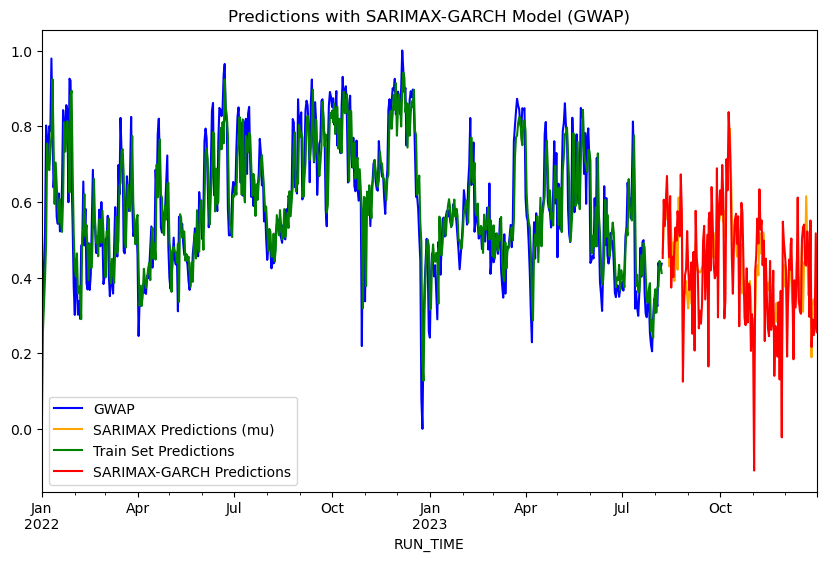

In [16]:
#Generate SARIMAX-GARCH predictions
%run GARCH.py

gwap_garch_predictions = garch_predict(
    'GWAP', 't', 'Garch', gwap_garch_fitted,
    GWAP_train,
    gwap_train_predict,
    gwap_test_predict
)

GWAP EGARCH

In [17]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    gwap_resid_train, 
    vol="EGARCH", 
    p_orders=[0,1], 
    q_orders=[0,1], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for EGARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with ged distribution: One of p or o must be strictly positive


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.008799. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.008799. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scal

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1
0,1,1,EGARCH,t,-1135.044060,-1117.564456,571.522030,16.339622,0.090314,0.260879,0.010817,0.851533,1.888448e-28
1,1,1,EGARCH,ged,-1133.027509,-1115.547905,570.513754,16.339622,0.090314,0.242965,0.013815,0.855350,3.963261e-31
2,1,0,EGARCH,t,-1125.289395,-1112.179692,565.644698,16.339622,0.090314,0.316605,0.001240,NaN,NaN
3,1,1,EGARCH,normal,-1124.214213,-1111.104510,565.107107,16.339622,0.090314,0.223248,0.029090,0.857173,1.182620e-28
4,1,0,EGARCH,ged,-1122.731715,-1109.622012,564.365858,16.339622,0.090314,0.282616,0.002392,NaN,NaN
5,1,0,EGARCH,normal,-1110.798889,-1102.059087,557.399445,16.339622,0.090314,0.243870,0.007038,NaN,NaN
6,0,1,EGARCH,normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,1,EGARCH,t,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,1,EGARCH,ged,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
#Fitting EGARCH model
%run GARCH.py

gwap_egarch_fitted = fit_garch('GWAP', 'EGARCH', 1, 1, 't', '2023-8-8', gwap_resid_complete)

                          Zero Mean - EGARCH Model Results                          
Dep. Variable:          gwap_resid_complete   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                           EGARCH   Log-Likelihood:                571.522
Distribution:      Standardized Student's t   AIC:                          -1135.04
Method:                  Maximum Likelihood   BIC:                          -1117.56
                                              No. Observations:                  584
Date:                      Sun, Mar 23 2025   Df Residuals:                      584
Time:                              12:46:59   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega     

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.008799. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




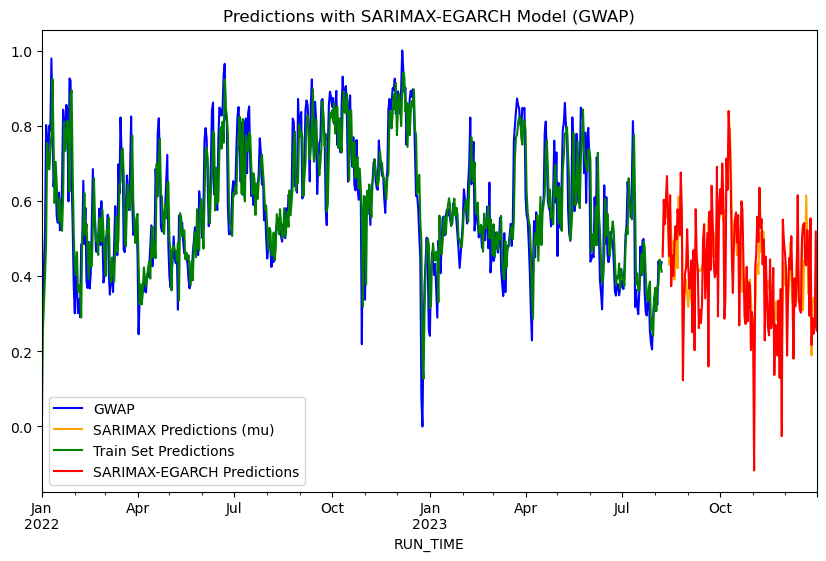

In [19]:
#Generate SARIMAX-EGARCH predictions
%run GARCH.py

gwap_egarch_predictions = garch_predict(
    'GWAP', 't', 'EGARCH', gwap_egarch_fitted,
    GWAP_train,
    gwap_train_predict,
    gwap_test_predict
)

LWAP Residual Analysis

In [20]:
#Generate residuals for LWAP

%run GARCH.py
lwap_resid_complete, lwap_resid_train = generate_resid(
    'LWAP',
    LWAP_train,
    LWAP_test,
    lwap_train_predict,
    lwap_test_predict,
    lwap_model_results
)

2022-01-01    0.255131
2022-01-02    0.076615
2022-01-03    0.110877
2022-01-04    0.118009
2022-01-05    0.314396
2022-01-06    0.016889
2022-01-07    0.021366
2022-01-08    0.131903
2022-01-09    0.059238
2022-01-10    0.222608
2022-01-11   -0.095587
2022-01-12   -0.156775
2022-01-13    0.095561
2022-01-14   -0.044380
2022-01-15   -0.093916
2022-01-16   -0.030605
2022-01-17    0.036764
2022-01-18   -0.085215
2022-01-19    0.006772
2022-01-20    0.113450
2022-01-21    0.246847
2022-01-22   -0.060335
2022-01-23    0.092300
2022-01-24    0.089013
2022-01-25    0.040407
2022-01-26   -0.157276
2022-01-27    0.314201
2022-01-28    0.015795
2022-01-29   -0.222902
2022-01-30   -0.150074
2022-01-31   -0.150720
2022-02-01   -0.136957
2022-02-02    0.083083
2022-02-03   -0.136970
2022-02-04   -0.074945
2022-02-05   -0.016096
2022-02-06   -0.086296
2022-02-07    0.201081
2022-02-08    0.018121
2022-02-09    0.099503
2022-02-10   -0.128333
2022-02-11    0.076817
2022-02-12   -0.151879
2022-02-13 

RUN_TIME
2022-01-01    0.255131
2022-01-02    0.076615
2022-01-03    0.110877
2022-01-04    0.118009
2022-01-05    0.314396
2022-01-06    0.016889
2022-01-07    0.021366
2022-01-08    0.131903
2022-01-09    0.059238
2022-01-10    0.222608
2022-01-11   -0.095587
2022-01-12   -0.156775
2022-01-13    0.095561
2022-01-14   -0.044380
2022-01-15   -0.093916
2022-01-16   -0.030605
2022-01-17    0.036764
2022-01-18   -0.085215
2022-01-19    0.006772
2022-01-20    0.113450
2022-01-21    0.246847
2022-01-22   -0.060335
2022-01-23    0.092300
2022-01-24    0.089013
2022-01-25    0.040407
2022-01-26   -0.157276
2022-01-27    0.314201
2022-01-28    0.015795
2022-01-29   -0.222902
2022-01-30   -0.150074
2022-01-31   -0.150720
2022-02-01   -0.136957
2022-02-02    0.083083
2022-02-03   -0.136970
2022-02-04   -0.074945
2022-02-05   -0.016096
2022-02-06   -0.086296
2022-02-07    0.201081
2022-02-08    0.018121
2022-02-09    0.099503
2022-02-10   -0.128333
2022-02-11    0.076817
2022-02-12   -0.151879
20

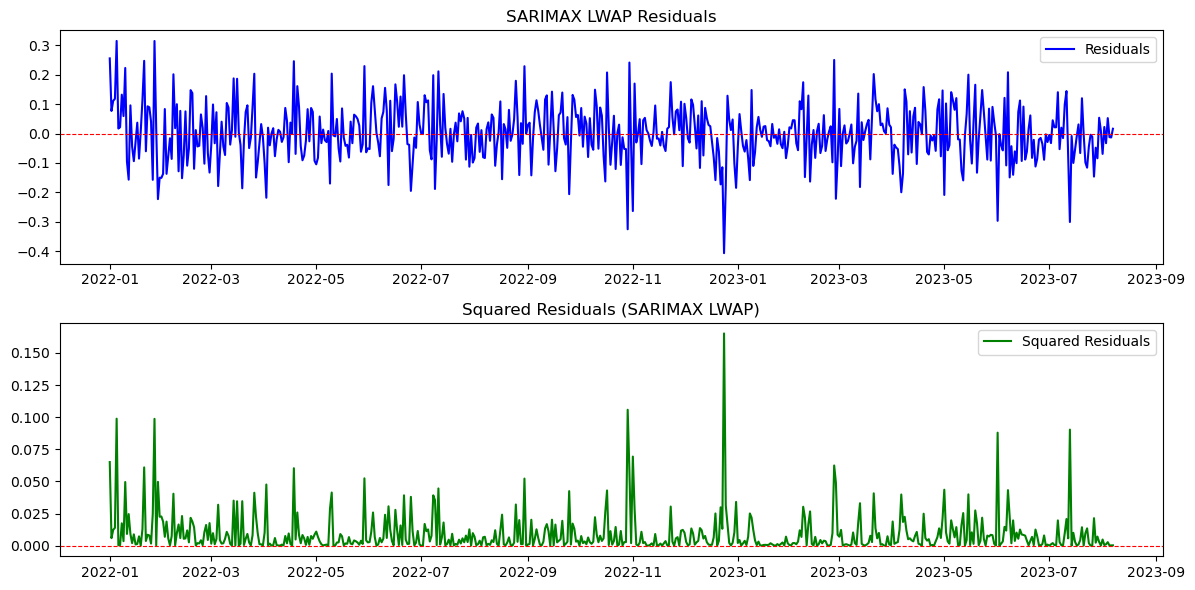

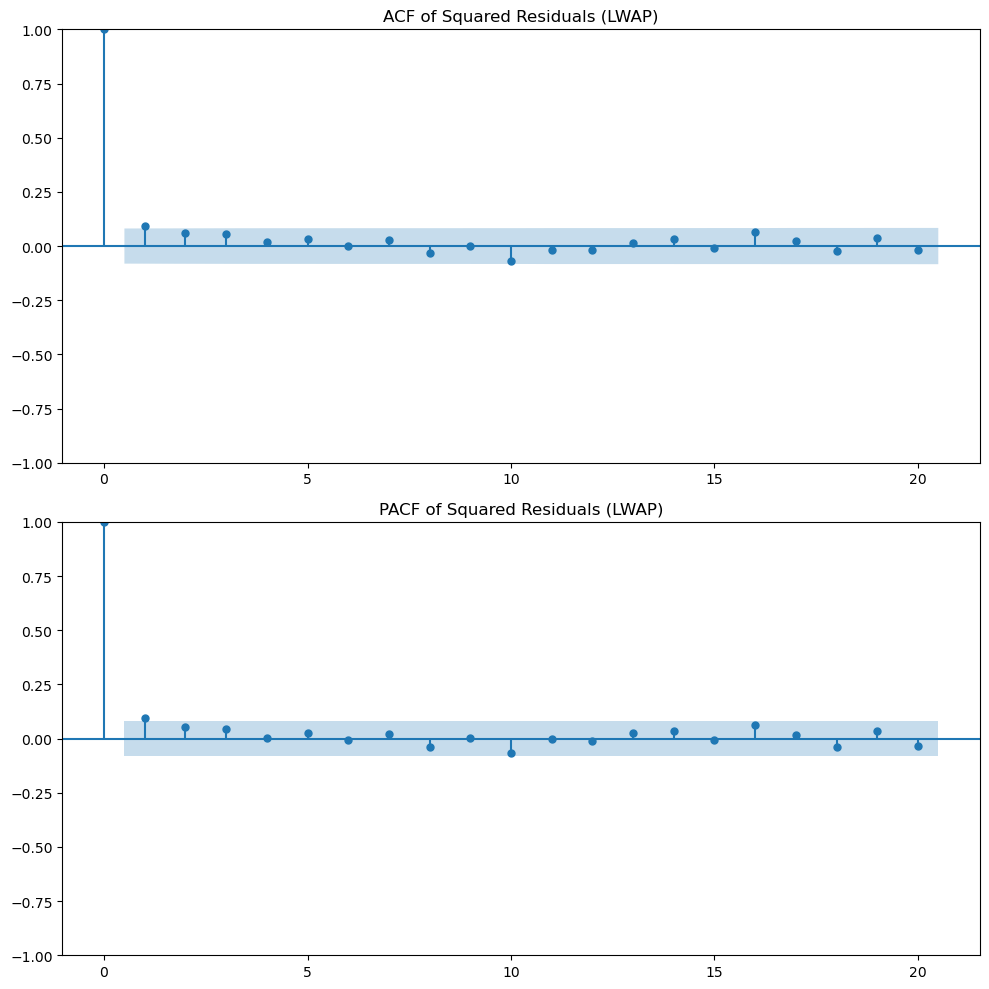

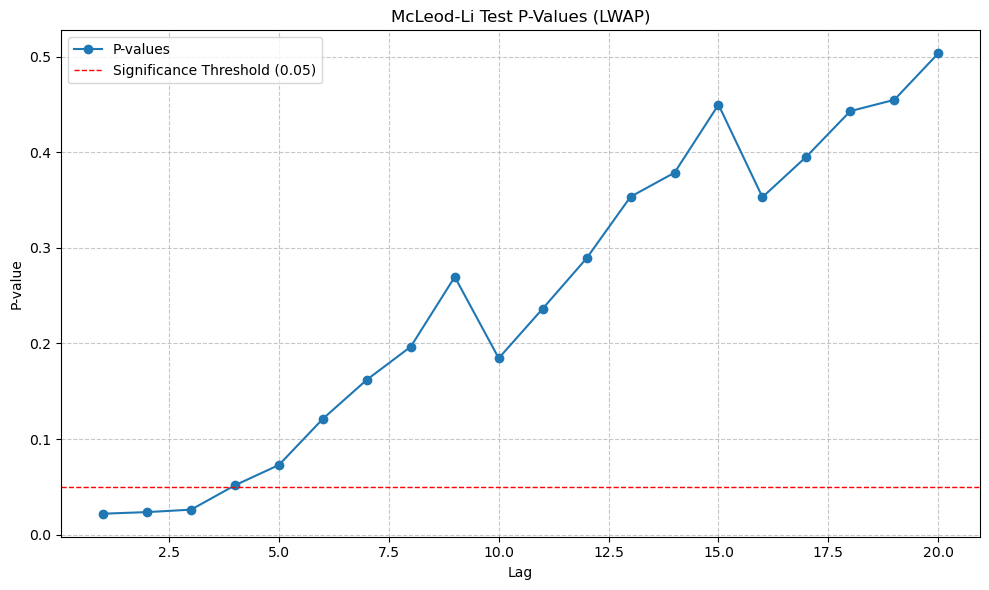

,Lag,PQ Test Stat,PQ p-value,LM Test Stat,LM p-value
0,1,5.245939,0.021998,5.331257,0.020946
1,2,7.485713,0.023686,7.250133,0.026647
2,3,9.242779,0.026231,8.364313,0.039053
3,4,9.405667,0.051722,8.288788,0.081554
4,5,10.080805,0.072978,9.606759,0.087176
5,6,10.081676,0.121254,10.999903,0.088379
6,7,10.497469,0.162091,11.653168,0.112557
7,8,11.089627,0.196672,12.372382,0.135346
8,9,11.089759,0.269607,12.238686,0.200185
9,10,13.752534,0.184581,14.346921,0.157747


In [21]:
#Conducting residual analysis
%run GARCH.py

garch_testing(lwap_resid_train, 'LWAP', max_lag=20)

In [22]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    lwap_resid_train, 
    vol="GARCH", 
    p_orders=[0,1], 
    q_orders=[0,1], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for GARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for GARCH(0,1) with ged distribution: One of p or o must be strictly positive


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.009234. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.009234. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scal

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1
0,1,1,GARCH,t,-1094.177435,-1076.697831,551.088718,14.346921,0.157747,0.111648,0.090634,0.652893,0.000142
1,1,1,GARCH,ged,-1092.350767,-1074.871163,550.175383,14.346921,0.157747,0.108745,0.113042,0.640719,0.000351
2,1,0,GARCH,t,-1090.073763,-1076.964061,548.036882,14.346921,0.157747,0.152771,0.045922,NaN,NaN
3,1,0,GARCH,ged,-1088.286656,-1075.176953,547.143328,14.346921,0.157747,0.147165,0.059209,NaN,NaN
4,1,1,GARCH,normal,-1087.229074,-1074.119371,546.614537,14.346921,0.157747,0.106621,0.146527,0.619363,0.002413
5,1,0,GARCH,normal,-1082.304789,-1073.564987,543.152395,14.346921,0.157747,0.141169,0.068464,NaN,NaN
6,0,1,GARCH,normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,1,GARCH,t,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,1,GARCH,ged,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
#Fitting GARCH model
%run GARCH.py

lwap_garch_fitted = fit_garch('LWAP', 'Garch', 1, 1, 't', '2023-8-8', lwap_resid_complete)

                          Zero Mean - GARCH Model Results                           
Dep. Variable:          lwap_resid_complete   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                            GARCH   Log-Likelihood:                551.089
Distribution:      Standardized Student's t   AIC:                          -1094.18
Method:                  Maximum Likelihood   BIC:                          -1076.70
                                              No. Observations:                  584
Date:                      Sun, Mar 23 2025   Df Residuals:                      584
Time:                              12:47:00   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
o

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.009234. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




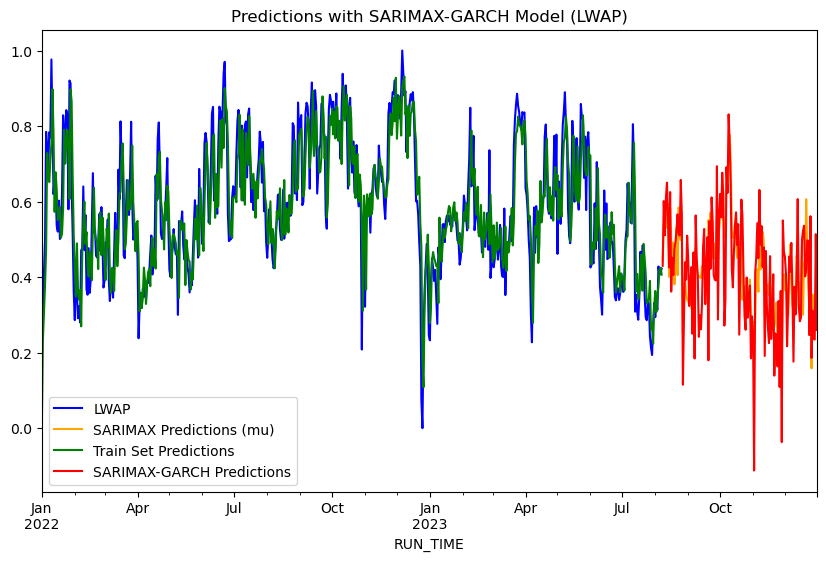

In [24]:
#Generate SARIMAX-GARCH predictions
%run GARCH.py

lwap_garch_predictions = garch_predict(
    'LWAP', 't', 'Garch', lwap_garch_fitted,
    LWAP_train,
    lwap_train_predict,
    lwap_test_predict
)

LWAP EGARCH

In [25]:
#Choosing order specification based on lowest AIC/BIC
%run GARCH.py

evaluate_garch(
    lwap_resid_train, 
    vol="EGARCH", 
    p_orders=[0,1], 
    q_orders=[0,1], 
    distributions=["normal", "t", "ged"], 
    sort_by="AIC"
)

Error for EGARCH(0,1) with normal distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with t distribution: One of p or o must be strictly positive
Error for EGARCH(0,1) with ged distribution: One of p or o must be strictly positive


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.009234. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.009234. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.


/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scal

,p,q,Volatility Model,Distribution,AIC,BIC,LLF,ARCH Stat,ARCH p-value,alpha_1,alpha_pval_1,beta_1,beta_pval_1
0,1,1,EGARCH,t,-1095.480654,-1078.001050,551.740327,14.346921,0.157747,0.256823,0.018317,0.763505,1.843283e-08
1,1,1,EGARCH,ged,-1093.784463,-1076.304859,550.892231,14.346921,0.157747,0.252190,0.019599,0.749044,3.208874e-08
2,1,0,EGARCH,t,-1091.544362,-1078.434659,548.772181,14.346921,0.157747,0.312343,0.002711,NaN,NaN
3,1,0,EGARCH,ged,-1089.535707,-1076.426004,547.767853,14.346921,0.157747,0.291316,0.003716,NaN,NaN
4,1,1,EGARCH,normal,-1088.845462,-1075.735759,547.422731,14.346921,0.157747,0.249343,0.023942,0.725129,7.947178e-07
5,1,0,EGARCH,normal,-1083.453394,-1074.713592,543.726697,14.346921,0.157747,0.272711,0.004782,NaN,NaN
6,0,1,EGARCH,normal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,0,1,EGARCH,t,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0,1,EGARCH,ged,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
#Fitting EGARCH model
%run GARCH.py

lwap_egarch_fitted = fit_garch('LWAP', 'EGARCH', 1, 1, 't', '2023-8-8', lwap_resid_complete)

                          Zero Mean - EGARCH Model Results                          
Dep. Variable:          lwap_resid_complete   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.002
Vol Model:                           EGARCH   Log-Likelihood:                551.740
Distribution:      Standardized Student's t   AIC:                          -1095.48
Method:                  Maximum Likelihood   BIC:                          -1078.00
                                              No. Observations:                  584
Date:                      Sun, Mar 23 2025   Df Residuals:                      584
Time:                              12:47:00   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega     

/opt/anaconda3/lib/python3.11/site-packages/arch/univariate/base.py:309: DataScaleWarning:

y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.009234. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.




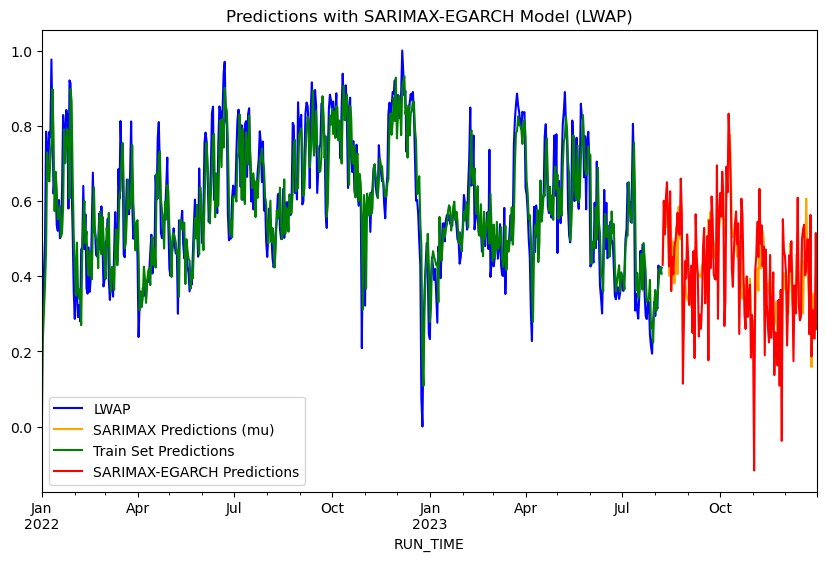

In [27]:
#Generate SARIMAX-GARCH predictions
%run GARCH.py

lwap_egarch_predictions = garch_predict(
    'LWAP', 't', 'EGARCH', lwap_egarch_fitted,
    LWAP_train,
    lwap_train_predict,
    lwap_test_predict
)

Applying inverse transformations

In [28]:
def prep_predictions(gwap_predictions, lwap_predictions):
    gwap_predictions_df = gwap_predictions.to_frame(name='GWAP')
    lwap_predictions_df = lwap_predictions.to_frame(name='LWAP')

    %run transformscript.py

    inverse_gwap_predictions = inverse_transform_data(gwap_predictions_df, 'SARIMAX', 'LUZ', 'GWAP')
    inverse_lwap_predictions = inverse_transform_data(lwap_predictions_df, 'SARIMAX', 'LUZ', 'LWAP')

    return inverse_gwap_predictions, inverse_lwap_predictions

In [29]:
#Preparing the predictions of the various time series models
inverse_gwap_sarimax_predictions, inverse_lwap_sarimax_predictions = prep_predictions(gwap_test_predict, lwap_test_predict)
inverse_gwap_garch_predictions, inverse_lwap_garch_predictions = prep_predictions(gwap_garch_predictions, lwap_garch_predictions)
inverse_gwap_egarch_predictions, inverse_lwap_egarch_predictions = prep_predictions(gwap_egarch_predictions, lwap_egarch_predictions)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator PowerTransformer from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator MinMaxScaler from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:376: InconsistentVersionWarning:

Trying to unpickle estimator Pipeline from version 1.6.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at

Mean Absolute Error (MAE) on Test Set for GWAP: 1037.2914453433011
Root Mean Squared Error (RMSE) on Test Set for GWAP: 1759.2181324758178
Mean Absolute Percentage Error (MAPE) on Test Set for GWAP: 18.151759257521803


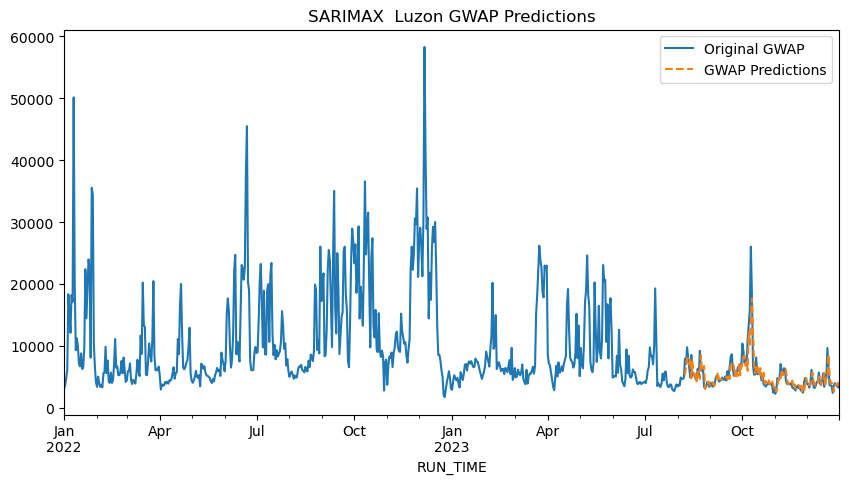

Mean Absolute Error (MAE) on Test Set for LWAP: 1141.056007123346
Root Mean Squared Error (RMSE) on Test Set for LWAP: 1902.362467124514
Mean Absolute Percentage Error (MAPE) on Test Set for LWAP: 19.133241072134023


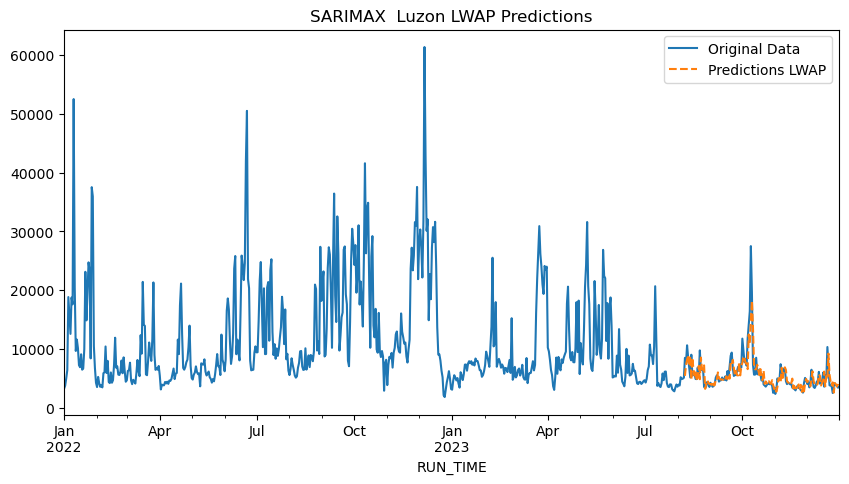

In [30]:
#Assessing SARIMAX model

%run SARIMAX.py
gwap_mae_test, gwap_rmse_test, mape_test_gwap, mape_test_lwap, lwap_rmse_test, lwap_rmse_test = evaluate_models(complete_luz_gwap, complete_luz_lwap, GWAP_test_original = untransformed_GWAP_test, GWAP_predictions_inverse= inverse_gwap_sarimax_predictions, LWAP_test_original=untransformed_LWAP_test, LWAP_predictions_inverse=inverse_lwap_sarimax_predictions, Region = 'Luzon', Volatility = '')

Mean Absolute Error (MAE) on Test Set for GWAP: 1574.2378573136014
Root Mean Squared Error (RMSE) on Test Set for GWAP: 2120.1267466651934
Mean Absolute Percentage Error (MAPE) on Test Set for GWAP: 30.990715936911638


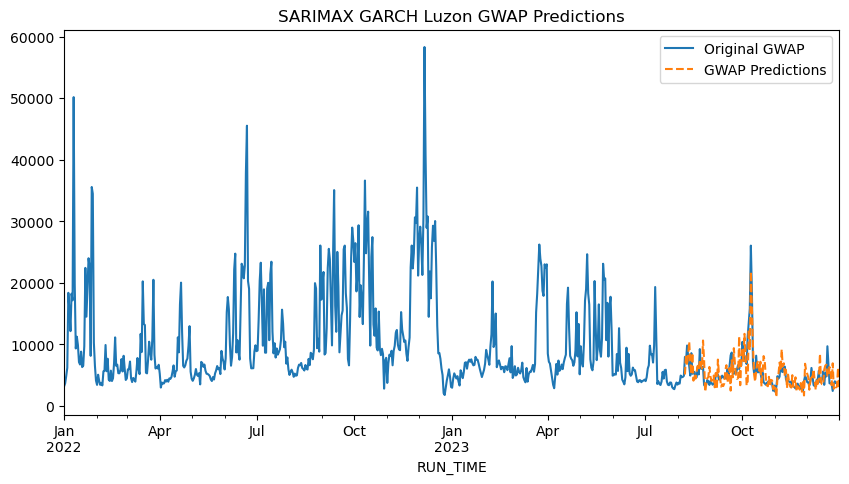

Mean Absolute Error (MAE) on Test Set for LWAP: 1750.7037356028275
Root Mean Squared Error (RMSE) on Test Set for LWAP: 2337.587198318977
Mean Absolute Percentage Error (MAPE) on Test Set for LWAP: 33.10757644168487


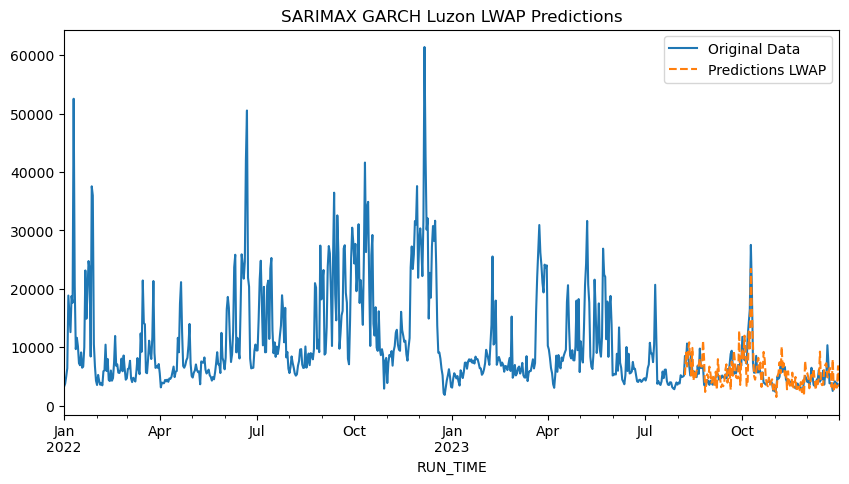

In [31]:
#Assessing SARIMAX-GARCH model

%run SARIMAX.py
gwap_mae_test, gwap_rmse_test, mape_test_gwap, mape_test_lwap, lwap_rmse_test, lwap_rmse_test = evaluate_models(complete_luz_gwap, complete_luz_lwap, GWAP_test_original = untransformed_GWAP_test, GWAP_predictions_inverse= inverse_gwap_garch_predictions, LWAP_test_original=untransformed_LWAP_test, LWAP_predictions_inverse=inverse_lwap_garch_predictions, Region = 'Luzon', Volatility = 'GARCH')

Mean Absolute Error (MAE) on Test Set for GWAP: 1586.492991888823
Root Mean Squared Error (RMSE) on Test Set for GWAP: 2134.806653882401
Mean Absolute Percentage Error (MAPE) on Test Set for GWAP: 31.31029662795608


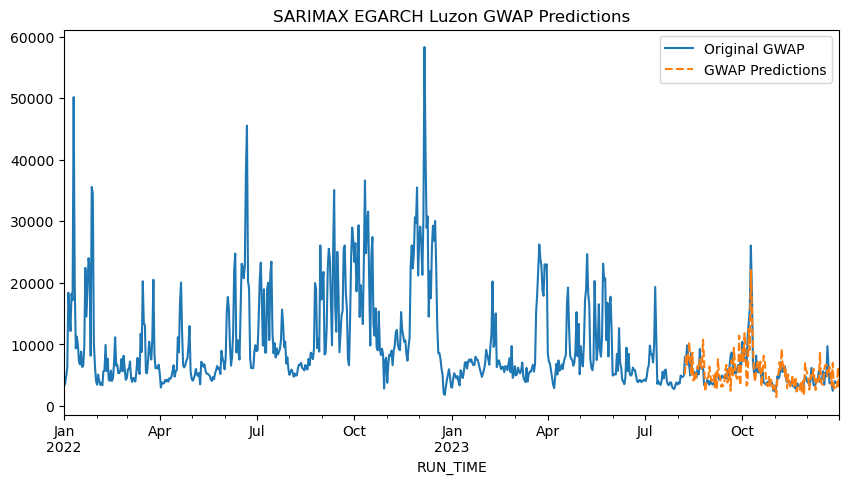

Mean Absolute Error (MAE) on Test Set for LWAP: 1759.4409418643584
Root Mean Squared Error (RMSE) on Test Set for LWAP: 2348.5880945102954
Mean Absolute Percentage Error (MAPE) on Test Set for LWAP: 33.32213348684499


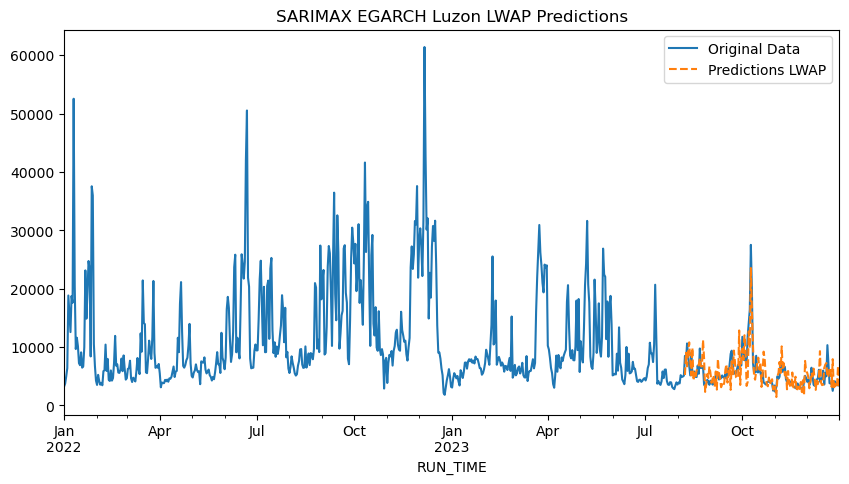

In [32]:
#Assessing SARIMAX-EGARCH model

%run SARIMAX.py
gwap_mae_test, gwap_rmse_test, mape_test_gwap, mape_test_lwap, lwap_rmse_test, lwap_rmse_test = evaluate_models(complete_luz_gwap, complete_luz_lwap, GWAP_test_original = untransformed_GWAP_test, GWAP_predictions_inverse= inverse_gwap_egarch_predictions, LWAP_test_original=untransformed_LWAP_test, LWAP_predictions_inverse=inverse_lwap_egarch_predictions, Region = 'Luzon', Volatility = 'EGARCH')